# Sprint 1 — Bus Patronage EDA (Victoria)

**Stream:** Team A — Cycling / Public Transport / Pedestrian mode shift &nbsp;·&nbsp; **Subgroup:** Bus
**Branch:** `feature/rd/teamA-bus`

**Dataset:** Monthly public transport patronage by mode — Transport Victoria Open Data (CC BY 4.0)
**Focus modes:** Metropolitan bus, Regional bus, Regional coach (V/Line)
**Coverage:** monthly, Jan 2018 → ~Mar 2026

This notebook works through the four Sprint 1 EDA tasks in order:
1. Explore and understand the data
2. Summarise it
3. Identify data-quality issues
4. Produce initial insights

Column names are auto-detected, so the notebook keeps working if the header spelling changes slightly.

---
### Data source & reproducibility
`data/raw/` is git-ignored, so the CSV is **not** committed. Download it once into the repo before running:

- **File:** `data/raw/monthly_public_transport_patronage_by_mode.csv`
- **Source (direct CSV):** https://opendata.transport.vic.gov.au/dataset/1ab35aa9-f21d-4f00-939b-60dade427d45/resource/74174b02-76bc-4d10-ae7c-401d90ef033c/download/monthly_public_transport_patronage_by_mode.csv
- **Downloaded:** _(record the date you downloaded it here)_

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


def find_project_root(marker: str = "config.yaml") -> Path:
    """Locate the repository root by walking up from the working directory.

    The root is identified by the presence of ``marker`` (default
    ``config.yaml``). This keeps the notebook working regardless of where
    JupyterLab is launched from, without hard-coding any absolute path.

    Parameters:
        marker (str): File name that marks the project root.

    Returns:
        Path: Absolute path to the project root.
    """
    base = Path.cwd().resolve()
    for parent in [base, *base.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(
        f"Could not locate project root (no '{marker}' found above {base})."
    )


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CSV_PATH = RAW_DIR / "monthly_public_transport_patronage_by_mode.csv"

print("Project root:", PROJECT_ROOT.name)
print("Reading    :", CSV_PATH.relative_to(PROJECT_ROOT))

Project root: Victoria-Urban-Planning
Reading    : data\raw\monthly_public_transport_patronage_by_mode.csv


## Step 1 — Explore and understand

Load the file, inspect its shape / columns, auto-detect the columns we need (defensive against header spelling), build a proper monthly `date`, and coerce the mode columns to numbers.

In [2]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Expected the patronage CSV at {CSV_PATH}.\n"
        "Download it from Transport Victoria Open Data (see the source link in the "
        "first markdown cell) and save it there, then re-run."
    )

df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
print("Shape (rows, cols):", df.shape)
print("Columns:", df.columns.tolist())


def find_one(frame, must_contain, must_not_contain=()):
    """Return the first column whose lower-cased name contains all of
    ``must_contain`` and none of ``must_not_contain``."""
    for c in frame.columns:
        cl = c.lower()
        if all(k in cl for k in must_contain) and not any(k in cl for k in must_not_contain):
            return c
    return None


year_col = find_one(df, ["year"])
month_col = find_one(df, ["month"], must_not_contain=["name"])

# The three bus modes: metropolitan bus, regional bus, regional coach (V/Line).
bus_cols = [c for c in df.columns if ("bus" in c.lower()) or ("coach" in c.lower())]
all_mode_cols = [c for c in df.columns
                 if any(k in c.lower() for k in ["train", "tram", "bus", "coach"])]

# Build a monthly date index from year + month.
df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
df[month_col] = pd.to_numeric(df[month_col], errors="coerce")
df["date"] = pd.to_datetime(
    df[year_col].astype("Int64").astype(str).str.zfill(4) + "-"
    + df[month_col].astype("Int64").astype(str).str.zfill(2) + "-01",
    format="%Y-%m-%d", errors="coerce",
)
df = df.sort_values("date").reset_index(drop=True)

# Ensure mode columns are numeric.
for c in all_mode_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Detected  year/month:", year_col, "/", month_col)
print("Bus/coach modes     :", bus_cols)
print("Date coverage       :", df["date"].min(), "->", df["date"].max())
df.head()

Shape (rows, cols): (99, 10)
Columns: ['Year', 'Month', 'Month name', 'Metropolitan train', 'Metropolitan tram', 'Metropolitan bus', 'V/Line train', 'V/Line coach', 'Regional bus', 'Unnamed: 9']
Detected  year/month: Year / Month
Bus/coach modes     : ['Metropolitan bus', 'V/Line coach', 'Regional bus']
Date coverage       : 2018-01-01 00:00:00 -> 2026-03-01 00:00:00


,Year,Month,Month name,Metropolitan train,Metropolitan tram,Metropolitan bus,V/Line train,V/Line coach,Regional bus,Unnamed: 9,date
0,2018,1,January,16809932,15231368,7568547,1466256,116568,721229,NaN,2018-01-01
1,2018,2,February,19554477,16980925,10487311,1522981,103197,1118494,NaN,2018-02-01
2,2018,3,March,22659010,19832126,11528895,1809774,117180,1224816,NaN,2018-03-01
3,2018,4,April,20312040,16919872,9592750,1684827,107480,946218,NaN,2018-04-01
4,2018,5,May,22768447,17691427,11263486,1790656,109456,1258704,NaN,2018-05-01


## Step 2 — Summarise

Descriptive statistics for the bus modes, the peak and trough month for each, calendar-year totals, a combined bus total, and bus's share of all public transport. A continuity check confirms the monthly series has no gaps.

In [3]:
print("=== Descriptive stats: bus modes ===")
display(df[bus_cols].describe().T)

print("\n=== Peak and trough month per bus mode ===")
for c in bus_cols:
    s = df[["date", c]].dropna()
    if s.empty:
        continue
    hi = s.loc[s[c].idxmax()]
    lo = s.loc[s[c].idxmin()]
    print(f"{c:>18}: max {int(hi[c]):>11,} ({hi['date']:%b %Y}) | "
          f"min {int(lo[c]):>11,} ({lo['date']:%b %Y})")

# Combined bus total and its share of all public transport.
df["bus_total"] = df[bus_cols].sum(axis=1)
df["pt_total"] = df[all_mode_cols].sum(axis=1)
df["bus_share_pct"] = 100 * df["bus_total"] / df["pt_total"]

# Annual totals (calendar year). First and last year are usually partial.
annual = df.groupby(year_col)[bus_cols + ["bus_total", "pt_total"]].sum()
annual["bus_share_pct"] = 100 * annual["bus_total"] / annual["pt_total"]
print("\n=== Annual totals (first/last year may be partial) ===")
display(annual)

# Continuity: are all months present across the span?
expected = pd.period_range(df["date"].min(), df["date"].max(), freq="M")
print(f"\nDistinct months present: {df['date'].nunique()} | expected across span: {len(expected)}")

=== Descriptive stats: bus modes ===


,count,mean,std,min,25%,50%,75%,max
Metropolitan bus,99.0,8.253926e+06,2.496425e+06,1507175.0,7211975.0,8809813.0,10094397.5,12082141.0
V/Line coach,99.0,9.025998e+04,2.834613e+04,17602.0,73894.0,104244.0,110913.5,128047.0
Regional bus,99.0,9.597872e+05,2.310276e+05,227342.0,839801.0,985731.0,1120144.0,1287180.0



=== Peak and trough month per bus mode ===
  Metropolitan bus: max  12,082,141 (May 2019) | min   1,507,175 (Apr 2020)
      V/Line coach: max     128,047 (Mar 2026) | min      17,602 (Apr 2020)
      Regional bus: max   1,287,180 (May 2019) | min     227,342 (Apr 2020)

=== Annual totals (first/last year may be partial) ===


,Metropolitan bus,V/Line coach,Regional bus,bus_total,pt_total,bus_share_pct
Year,,,,,,
2018,120803552,1325061,12904355,135032968,605292158,22.308726
2019,123691851,1301809,13176821,138170481,603083274,22.910680
2020,57630318,624059,8267337,66521714,226823636,29.327505
2021,62145077,636571,8453615,71235263,243130111,29.299235
2022,87446196,851753,11474517,99772466,379404227,26.297141
2023,109898208,1153582,13324469,124376259,466669113,26.651916
2024,115930767,1346508,12707704,129984979,501472879,25.920640
2025,112422690,1358877,11824770,125606337,490207817,25.623079
2026,27170064,337518,2885343,30392925,126036296,24.114423



Distinct months present: 99 | expected across span: 99


## Step 3 — Data-quality issues

Checks for missing values, duplicate months, gaps in the monthly sequence, the two-month reporting lag (trailing provisional months), and COVID-era lows. The COVID lows are **genuine** lockdown effects, so we verify rather than delete them.

In [4]:
from pprint import pprint

quality = {}

# 1) Missing values per mode column.
quality["missing_per_column"] = df[all_mode_cols].isna().sum().to_dict()

# 2) Duplicate (year, month) rows.
quality["duplicate_year_month_rows"] = int(df.duplicated(subset=[year_col, month_col]).sum())

# 3) Gaps in the monthly sequence.
full = pd.period_range(df["date"].min(), df["date"].max(), freq="M")
present = df["date"].dt.to_period("M")
quality["missing_months"] = [str(g) for g in sorted(set(full) - set(present))]

# 4) Trailing incomplete months (2-month lag): flag last months far below the trailing median.
tail_flags = []
for c in bus_cols:
    s = df.set_index("date")[c].dropna()
    if len(s) > 14:
        med12 = s.iloc[-14:-2].median()
        for dt, val in s.iloc[-3:].items():
            if pd.notna(med12) and med12 > 0 and val < 0.5 * med12:
                tail_flags.append((c, f"{dt:%b %Y}", int(val), int(med12)))
quality["suspicious_trailing_low_months"] = tail_flags

# 5) COVID-like lows (likely real lockdown months, NOT errors -- verify, don't drop).
low = df.loc[df["bus_total"] < 0.25 * df["bus_total"].median(), ["date", "bus_total"]]
quality["covid_like_low_months"] = [(f"{d:%b %Y}", int(v))
                                    for d, v in zip(low["date"], low["bus_total"])]

# 6) Any mode column that did not parse as numeric.
quality["non_numeric_mode_cols"] = [c for c in all_mode_cols
                                    if not np.issubdtype(df[c].dtype, np.number)]

pprint(quality)

{'covid_like_low_months': [('Apr 2020', 1752119),
                           ('Aug 2020', 2155133),
                           ('Sep 2020', 2442295)],
 'duplicate_year_month_rows': 0,
 'missing_months': [],
 'missing_per_column': {'Metropolitan bus': 0,
                        'Metropolitan train': 0,
                        'Metropolitan tram': 0,
                        'Regional bus': 0,
                        'V/Line coach': 0,
                        'V/Line train': 0},
 'non_numeric_mode_cols': [],
 'suspicious_trailing_low_months': []}


## Step 4 — Initial insights & visualisations

Five views: the three bus modes over time, bus's share of total PT (a mode-shift signal), the COVID collapse-and-recovery against a 2019 baseline, seasonality by calendar month, and year-on-year growth.

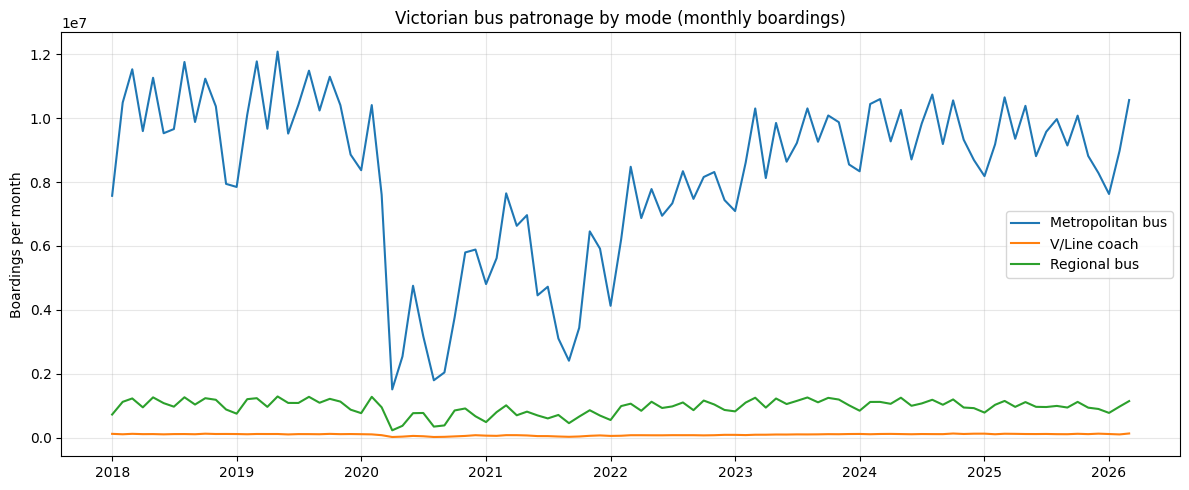

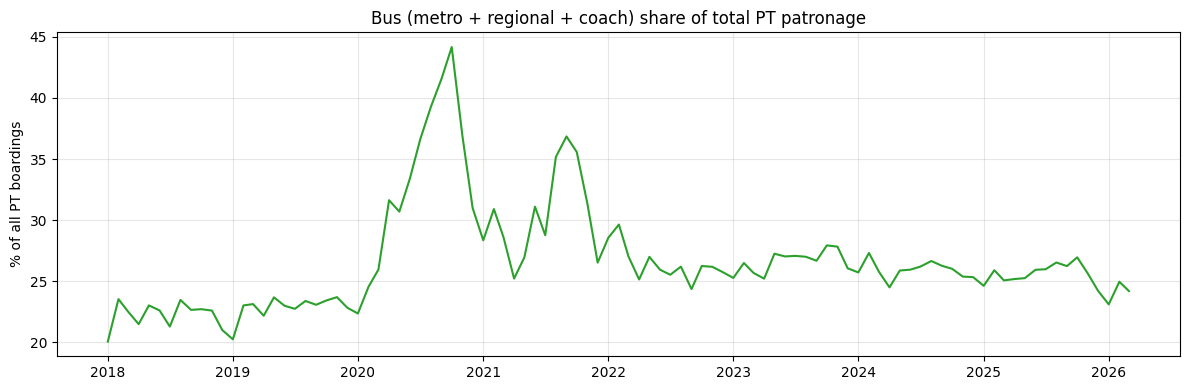

=== COVID collapse and recovery vs 2019 ===


,mode,2019_avg,trough,trough_month,drop_vs_2019_%,latest,latest_month,recovery_vs_2019_%
0,Metropolitan bus,10307654,1507175,Apr 2020,85.4,10566169,Mar 2026,102.5
1,V/Line coach,108484,17602,Apr 2020,83.8,128047,Mar 2026,118.0
2,Regional bus,1098068,227342,Apr 2020,79.3,1142533,Mar 2026,104.0


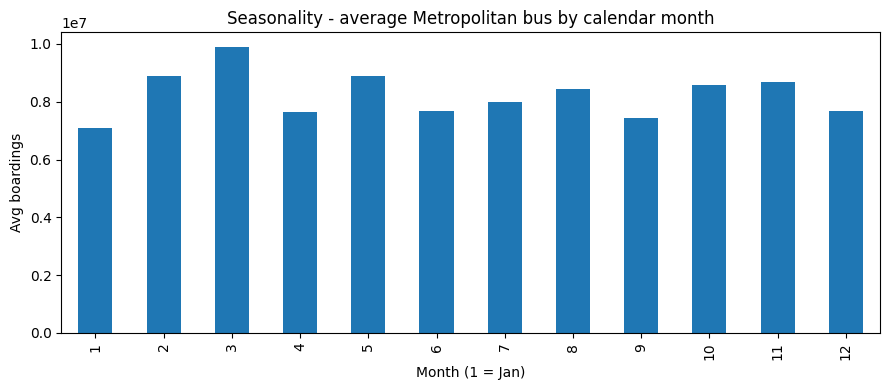

=== Year-on-year growth, combined bus total (%) ===


Year
2018     NaN
2019     2.3
2020   -51.9
2021     7.1
2022    40.1
2023    24.7
2024     4.5
2025    -3.4
2026   -75.8
Name: bus_total, dtype: float64

In [5]:
# (a) The three bus modes over time.
fig, ax = plt.subplots(figsize=(12, 5))
for c in bus_cols:
    ax.plot(df["date"], df[c], label=c)
ax.set_title("Victorian bus patronage by mode (monthly boardings)")
ax.set_ylabel("Boardings per month")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# (b) Bus share of total public transport (mode-shift signal).
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["bus_share_pct"], color="tab:green")
ax.set_title("Bus (metro + regional + coach) share of total PT patronage")
ax.set_ylabel("% of all PT boardings")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# (c) COVID collapse and recovery vs 2019 baseline, per mode.
base_year = 2019
rows = []
for c in bus_cols:
    base = df.loc[df[year_col] == base_year, c].mean()
    idx_min = df[c].idxmin()
    idx_last = df[c].dropna().index[-1]
    trough, trough_dt = df.loc[idx_min, c], df.loc[idx_min, "date"]
    latest, latest_dt = df.loc[idx_last, c], df.loc[idx_last, "date"]
    rows.append({
        "mode": c,
        "2019_avg": round(base) if pd.notna(base) else np.nan,
        "trough": int(trough), "trough_month": f"{trough_dt:%b %Y}",
        "drop_vs_2019_%": round(100 * (1 - trough / base), 1) if base else np.nan,
        "latest": int(latest), "latest_month": f"{latest_dt:%b %Y}",
        "recovery_vs_2019_%": round(100 * latest / base, 1) if base else np.nan,
    })
print("=== COVID collapse and recovery vs 2019 ===")
display(pd.DataFrame(rows))

# (d) Seasonality: average by calendar month (metro bus as the example).
metro = next((c for c in bus_cols if "metro" in c.lower()), bus_cols[0])
season = df.groupby(month_col)[metro].mean()
fig, ax = plt.subplots(figsize=(9, 4))
season.plot(kind="bar", ax=ax, color="tab:blue")
ax.set_title(f"Seasonality - average {metro} by calendar month")
ax.set_xlabel("Month (1 = Jan)")
ax.set_ylabel("Avg boardings")
plt.tight_layout()
plt.show()

# (e) Year-on-year growth of the combined bus total.
yoy = annual["bus_total"].pct_change().mul(100).round(1)
print("=== Year-on-year growth, combined bus total (%) ===")
display(yoy)

## Data-engineering output — tidy monthly table

Persist a clean **long-format** table (one row per month per bus mode) to `data/processed/`, with an `is_provisional` flag on the most recent two months (the reporting lag). This is the hand-off artifact for the rest of Team A. `data/processed/` is git-ignored, so the file stays local while the code that reproduces it is committed.

In [6]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Long (tidy) format: one row per month per bus mode.
tidy = df.melt(
    id_vars=["date", year_col, month_col],
    value_vars=bus_cols,
    var_name="mode",
    value_name="boardings",
).sort_values(["date", "mode"]).reset_index(drop=True)

# Flag the trailing provisional months (two-month reporting lag).
provisional_cutoff = df["date"].max() - pd.DateOffset(months=1)
tidy["is_provisional"] = tidy["date"] >= provisional_cutoff

out_path = PROCESSED_DIR / "bus_patronage_monthly_tidy.csv"
tidy.to_csv(out_path, index=False)
print(f"Wrote {len(tidy):,} rows -> {out_path.relative_to(PROJECT_ROOT)}")
tidy.tail(9)

Wrote 297 rows -> data\processed\bus_patronage_monthly_tidy.csv


,date,Year,Month,mode,boardings,is_provisional
288,2026-01-01,2026,1,Metropolitan bus,7624940,False
289,2026-01-01,2026,1,Regional bus,771902,False
290,2026-01-01,2026,1,V/Line coach,110891,False
291,2026-02-01,2026,2,Metropolitan bus,8978955,True
292,2026-02-01,2026,2,Regional bus,970908,True
293,2026-02-01,2026,2,V/Line coach,98580,True
294,2026-03-01,2026,3,Metropolitan bus,10566169,True
295,2026-03-01,2026,3,Regional bus,1142533,True
296,2026-03-01,2026,3,V/Line coach,128047,True


## Findings, caveats & next steps

**Passenger view**
- A sharp structural break from ~March 2020: bus patronage collapses and recovers only partially. Metropolitan bus is hit hardest in absolute terms.
- Divergent recovery: bus — especially regional and coach, which are less CBD-commuter-dependent — tends to recover to a higher share of its 2019 baseline than metro rail. A rising **bus share** of total PT since 2020 is a genuine mode-shift signal.
- Seasonality: a January trough (summer, schools out) and softer school-holiday months.

**Transport-planning view**
- Occasional V/Line coach spikes line up with rail disruptions (coach patronage includes rail-replacement services).
- **Scope limit (important):** this dataset is *statewide totals by mode*. It captures the COVID break and state-level mode shift, but it **cannot isolate the effect of a specific streetscape intervention on a specific street**. That signal needs route/stop-level bus data (GTFS + stop boardings) intersected with intervention corridors — the focus of the next notebook.

**Data-quality view**
- Metro/regional bus figures are modelled from myki touch-on rates (survey-based); regional bus mixes in operator statistical-return estimates; V/Line coach includes replacements — so absolute counts are indicative, not a census.
- Two-month reporting lag: the most recent 1–2 months are provisional (flagged in the tidy output) and usually read low — trim before trend claims.
- Raw boardings, no population normalisation. Per-capita / fair mode-share comparisons need ABS population, deferred until the August Census release (per the project README).

**Next steps**
- `01_bus_gtfs_spatial_eda.ipynb`: load the Victorian GTFS schedule, filter to bus, link routes → trips → stop_times → stops, and map stop / route coverage. Reproject stops from EPSG:4326 to the projected EPSG:7899 for any distance or buffer work (repo CRS rule).
- Bridge toward corridor-level before/after by buffering intervention sites (~20 m, per `config.yaml`) and selecting bus stops that fall inside them.